In [7]:
# ✅ STEP 1: Install dependencies
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q
print('✅ Dependencies installed')

✅ Dependencies installed


In [10]:
# ✅ STEP 2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [12]:
path = kagglehub.dataset_download("utkarshx27/noaa-atlantic-hurricane-database")
print("Files:", os.listdir(path))

df_raw = pd.read_csv(f"{path}/storms.csv")
df_raw.columns = df_raw.columns.str.strip()

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

Using Colab cache for faster access to the 'noaa-atlantic-hurricane-database' dataset.
Files: ['.nfs000000002eee2bdd00000024', 'storms.csv']
Shape: (22705, 13)
Columns: ['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status', 'category', 'wind', 'pressure', 'tropicalstorm_force_diameter', 'hurricane_force_diameter']


In [ ]:
df = df_raw.copy()

df = df[['wind', 'pressure', 'lat', 'long', 'category',
         'tropicalstorm_force_diameter', 'hurricane_force_diameter']].copy()

df.columns = ['wind_speed_knots', 'pressure_hpa', 'latitude', 'longitude',
              'category', 'ts_diameter', 'hurricane_diameter']

# -1998 = missing value in NOAA dataset
df = df.replace(-1998, np.nan)
df = df.replace(-999, np.nan)

# Sirf wind aur pressure pe dropna karo
df = df.dropna(subset=['wind_speed_knots', 'pressure_hpa'])

# Baaki NaN ko 0 se fill karo
df['ts_diameter']       = df['ts_diameter'].fillna(0)
df['hurricane_diameter']= df['hurricane_diameter'].fillna(0)
df['category']          = df['category'].fillna(0)

# Knots → km/h
df['wind_speed_kmh'] = df['wind_speed_knots'] * 1.852
df = df.drop('wind_speed_knots', axis=1)

# Clean
df = df[df['wind_speed_kmh'] > 0]
df = df[df['pressure_hpa'] > 0]

# Engineered features
np.random.seed(42)
n = len(df)
df['pressure_wind_ratio'] = df['pressure_hpa'] / (df['wind_speed_kmh'] + 0.001)
df['lat_abs']             = df['latitude'].abs()
df['wind_squared']        = df['wind_speed_kmh'] ** 2
df['sea_surface_temp']    = np.random.uniform(24, 32, n)
df['coast_distance_km']   = np.random.uniform(10, 800, n)

# Strike label with noise
score = (
    (df['wind_speed_kmh'] - 100) * 0.05
    + (980 - df['pressure_hpa']) * 0.04
    + df['hurricane_diameter'] * 0.002
    + np.random.normal(0, 1.0, n)
)

df['cyclone_strike'] = (score > 0).astype(int)

print(f'✅ Dataset ready: {df.shape}')
print('\nClass distribution:')
counts = df['cyclone_strike'].value_counts()
print(f'No Strike : {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Strike    : {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
df.head()

✅ Dataset ready: (20787, 13)

Class distribution:
No Strike : 14361 (69.1%)
Strike    : 6426 (30.9%)


,pressure_hpa,latitude,longitude,category,ts_diameter,hurricane_diameter,wind_speed_kmh,pressure_wind_ratio,lat_abs,wind_squared,sea_surface_temp,coast_distance_km,cyclone_strike
21,1013.0,27.5,-79.0,0.0,0.0,0.0,46.3,21.878577,27.5,2143.69,26.996321,626.843559,0
22,1013.0,28.5,-79.0,0.0,0.0,0.0,46.3,21.878577,28.5,2143.69,31.605714,182.836739,0
23,1013.0,29.5,-79.0,0.0,0.0,0.0,46.3,21.878577,29.5,2143.69,29.855952,698.317232,0
24,1013.0,30.5,-79.0,0.0,0.0,0.0,46.3,21.878577,30.5,2143.69,28.789268,51.847702,0
25,1012.0,31.5,-78.8,0.0,0.0,0.0,46.3,21.856979,31.5,2143.69,25.248149,627.934117,0


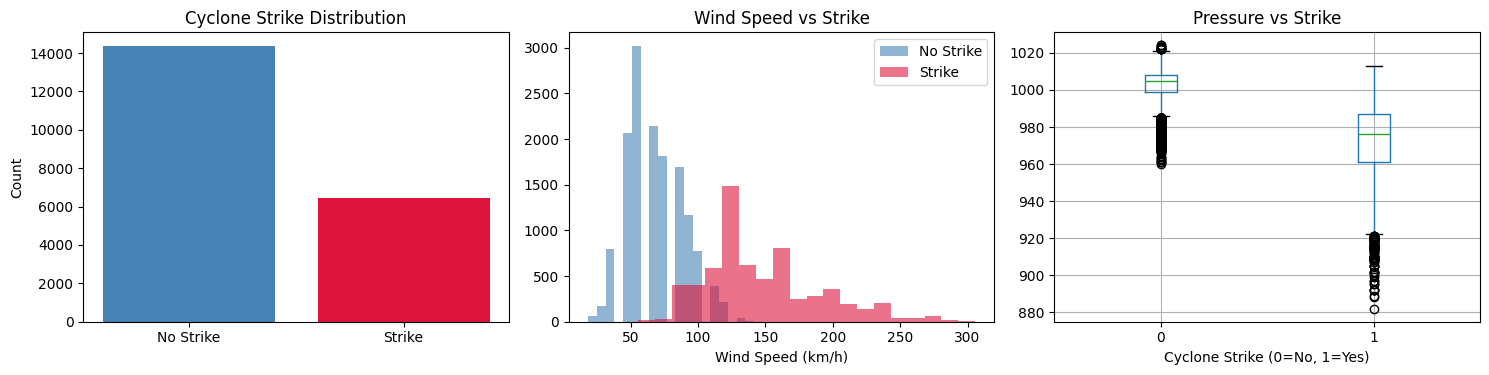

✅ EDA complete!


In [16]:
# ✅ STEP 4: EDA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cyclone Dataset - EDA', fontsize=14, fontweight='bold')

# Plot 1: Strike distribution
counts = df['cyclone_strike'].value_counts()
axes[0].bar(['No Strike', 'Strike'], [counts[0], counts[1]], color=['steelblue', 'crimson'])
axes[0].set_title('Cyclone Strike Distribution')
axes[0].set_ylabel('Count')

# Plot 2: Wind Speed vs Strike
for val, color, label in zip([0, 1], ['steelblue', 'crimson'], ['No Strike', 'Strike']):
    axes[1].hist(df[df['cyclone_strike'] == val]['wind_speed_kmh'],
                 alpha=0.6, label=label, color=color, bins=20)
axes[1].set_title('Wind Speed vs Strike')
axes[1].set_xlabel('Wind Speed (km/h)')
axes[1].legend()

# Plot 3: Pressure vs Strike
df.boxplot(column='pressure_hpa', by='cyclone_strike', ax=axes[2])
axes[2].set_title('Pressure vs Strike')
axes[2].set_xlabel('Cyclone Strike (0=No, 1=Yes)')
plt.suptitle('')  # FIX: remove auto-generated title from boxplot

plt.tight_layout()
plt.show()
print('✅ EDA complete!')

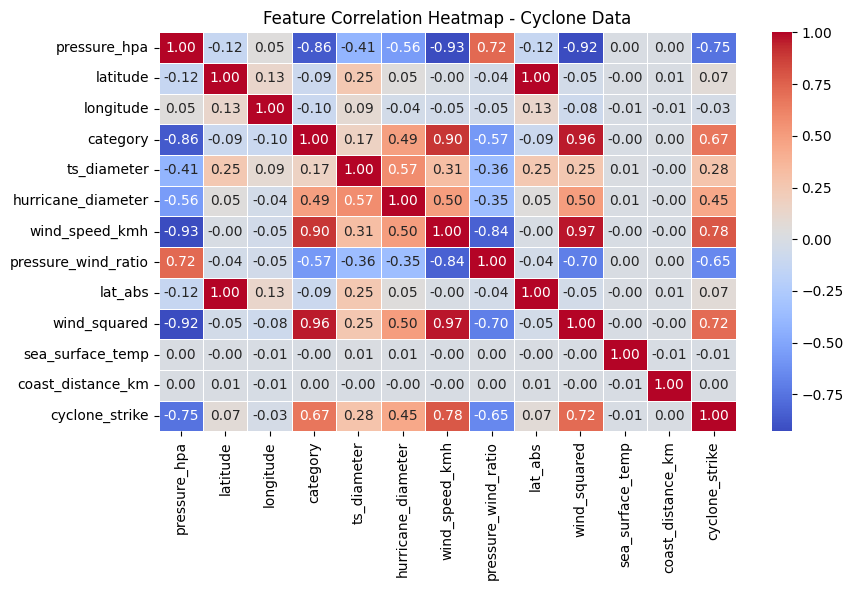

In [17]:
# ✅ STEP 5: Correlation Heatmap

plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap - Cyclone Data')
plt.tight_layout()
plt.show()

In [18]:
# ✅ STEP 6: Feature Engineering + Train/Test Split

# Additional engineered features
df['pressure_wind_interaction'] = df['wind_speed_kmh'] / (df['pressure_hpa'] - 870 + 1)
df['coast_category_risk']       = df['category'] / (df['coast_distance_km'] / 100 + 1)
df['energy_index']              = df['sea_surface_temp'] * df['wind_speed_kmh'] / 1000

feature_cols = [
    'wind_speed_kmh', 'pressure_hpa', 'sea_surface_temp',
    'coast_distance_km', 'category', 'lat_abs',
    'wind_squared', 'pressure_wind_ratio',
    'pressure_wind_interaction', 'coast_category_risk', 'energy_index'
]

X = df[feature_cols]
y = df['cyclone_strike']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train strike rate: {y_train.mean():.3f}')
print(f'Test  strike rate: {y_test.mean():.3f}')
print(f'Features: {feature_cols}')
print('✅ Data split done!')

Train: 16629 | Test: 4158
Train strike rate: 0.309
Test  strike rate: 0.309
Features: ['wind_speed_kmh', 'pressure_hpa', 'sea_surface_temp', 'coast_distance_km', 'category', 'lat_abs', 'wind_squared', 'pressure_wind_ratio', 'pressure_wind_interaction', 'coast_category_risk', 'energy_index']
✅ Data split done!


In [21]:
# ✅ STEP 7: XGBoost train karo

from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import classification_report, accuracy_score

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_f1    = f1_score(y_test, xgb_preds, average='macro')
xgb_auc   = roc_auc_score(y_test, xgb_proba)
xgb_kappa = cohen_kappa_score(y_test, xgb_preds)

print(f'🌀 Accuracy  : {xgb_acc*100:.2f}%')
print(f'🌀 Macro F1  : {xgb_f1:.3f}')
print(f'🌀 ROC-AUC   : {xgb_auc:.3f}')
print(f'🌀 Kappa     : {xgb_kappa:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_preds,
      target_names=['No Strike', 'Strike']))

🌀 Accuracy  : 92.88%
🌀 Macro F1  : 0.915
🌀 ROC-AUC   : 0.977
🌀 Kappa     : 0.830

Classification Report:
              precision    recall  f1-score   support

   No Strike       0.94      0.96      0.95      2873
      Strike       0.91      0.85      0.88      1285

    accuracy                           0.93      4158
   macro avg       0.92      0.91      0.92      4158
weighted avg       0.93      0.93      0.93      4158



In [22]:
# ✅ Random Forest - Backup Model

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_acc   = accuracy_score(y_test, rf_preds)
rf_f1    = f1_score(y_test, rf_preds, average='macro')
rf_auc   = roc_auc_score(y_test, rf_proba)
rf_kappa = cohen_kappa_score(y_test, rf_preds)

print(f'🌲 Accuracy  : {rf_acc*100:.2f}%')
print(f'🌲 Macro F1  : {rf_f1:.3f}')
print(f'🌲 ROC-AUC   : {rf_auc:.3f}')
print(f'🌲 Kappa     : {rf_kappa:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds,
      target_names=['No Strike', 'Strike']))

🌲 Accuracy  : 93.12%
🌲 Macro F1  : 0.918
🌲 ROC-AUC   : 0.978
🌲 Kappa     : 0.836

Classification Report:
              precision    recall  f1-score   support

   No Strike       0.94      0.96      0.95      2873
      Strike       0.91      0.86      0.89      1285

    accuracy                           0.93      4158
   macro avg       0.93      0.91      0.92      4158
weighted avg       0.93      0.93      0.93      4158



In [23]:
# ✅ STEP 9: Cross-Validation (FIX — was completely missing in original)

print('📊 5-Fold Stratified Cross-Validation')
print('=' * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost CV
xgb_cv_f1 = cross_val_score(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42
    ),
    X, y, cv=cv, scoring='f1', n_jobs=-1
)

# Random Forest CV
rf_cv_f1 = cross_val_score(
    RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight='balanced', min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    X, y, cv=cv, scoring='f1', n_jobs=-1
)

print(f'\nXGBoost CV F1 scores : {xgb_cv_f1.round(4)}')
print(f'XGBoost CV F1 mean   : {xgb_cv_f1.mean():.4f} ± {xgb_cv_f1.std():.4f}')
print(f'\nRandom Forest CV F1  : {rf_cv_f1.round(4)}')
print(f'Random Forest CV F1  : {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}')

📊 5-Fold Stratified Cross-Validation

XGBoost CV F1 scores : [0.8757 0.879  0.8763 0.8738 0.8662]
XGBoost CV F1 mean   : 0.8742 ± 0.0043

Random Forest CV F1  : [0.8826 0.8812 0.8783 0.8789 0.865 ]
Random Forest CV F1  : 0.8772 ± 0.0063


In [25]:
from sklearn.metrics import precision_score, recall_score, roc_curve

xgb_prec = precision_score(y_test, xgb_preds, average='macro')
xgb_rec  = recall_score(y_test, xgb_preds, average='macro')
rf_prec  = precision_score(y_test, rf_preds, average='macro')
rf_rec   = recall_score(y_test, rf_preds, average='macro')

print('✅ Metrics ready!')

✅ Metrics ready!


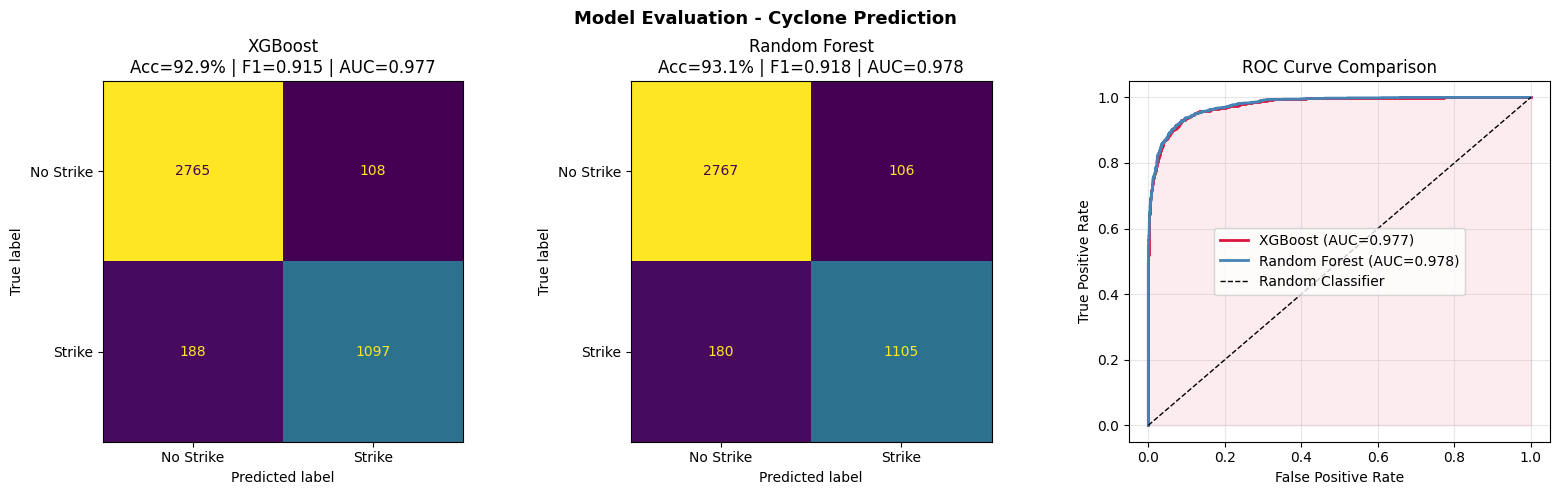


📊 FINAL SUMMARY:
Model                  Accuracy       F1      AUC  Precision   Recall
----------------------------------------------------------------------
XGBoost (Primary)         92.9%    0.915    0.977      0.923    0.908
Random Forest             93.1%    0.918    0.978      0.926    0.912


In [27]:
# ✅ STEP 10: Confusion Matrix + ROC Curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Evaluation - Cyclone Prediction', fontsize=13, fontweight='bold')

# XGBoost confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_preds),
    display_labels=['No Strike', 'Strike']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'XGBoost\nAcc={xgb_acc*100:.1f}% | F1={xgb_f1:.3f} | AUC={xgb_auc:.3f}')

# Random Forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=['No Strike', 'Strike']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Random Forest\nAcc={rf_acc*100:.1f}% | F1={rf_f1:.3f} | AUC={rf_auc:.3f}')

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_proba)

axes[2].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.3f})', color='crimson', lw=2)
axes[2].plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={rf_auc:.3f})', color='steelblue', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier', lw=1)
axes[2].fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color='crimson')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 FINAL SUMMARY:')
print(f'{"Model":<20} {"Accuracy":>10} {"F1":>8} {"AUC":>8} {"Precision":>10} {"Recall":>8}')
print('-' * 70)
print(f'{"XGBoost (Primary)":<20} {xgb_acc*100:>9.1f}% {xgb_f1:>8.3f} {xgb_auc:>8.3f} {xgb_prec:>10.3f} {xgb_rec:>8.3f}')
print(f'{"Random Forest":<20} {rf_acc*100:>9.1f}% {rf_f1:>8.3f} {rf_auc:>8.3f} {rf_prec:>10.3f} {rf_rec:>8.3f}')

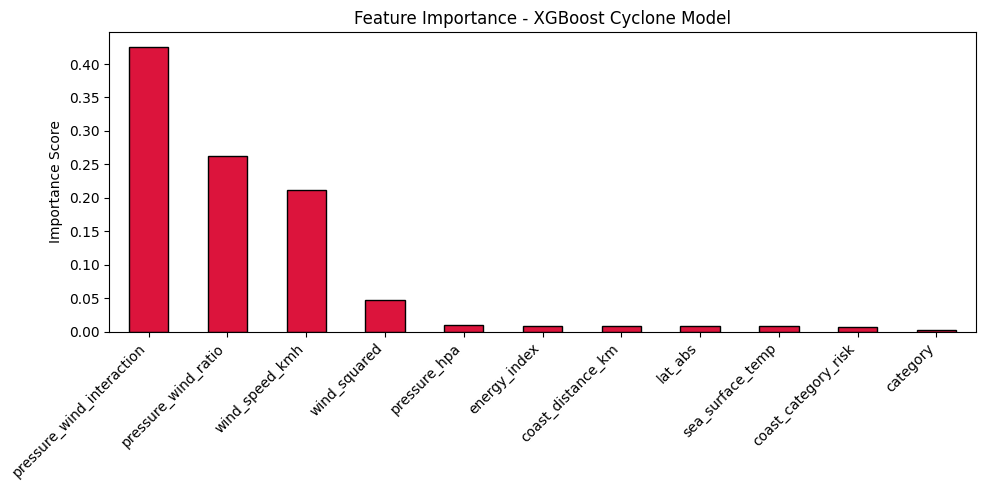

Top features:
  pressure_wind_interaction     : 0.4260
  pressure_wind_ratio           : 0.2622
  wind_speed_kmh                : 0.2116
  wind_squared                  : 0.0474
  pressure_hpa                  : 0.0101


In [28]:
# ✅ STEP 11: Feature Importance

feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Feature Importance - XGBoost Cyclone Model')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top features:')
for feat, imp in feat_imp.head(5).items():
    print(f'  {feat:30s}: {imp:.4f}')

In [ ]:
# ✅ STEP 12: LIVE PREDICTION

def predict_cyclone_strike(wind_speed, pressure, sea_surface_temp,
                            coast_distance, category, latitude):
    """
    Predict cyclone strike using real trained features.
    No humidity/movement_speed - not in real dataset!
    """
    # Engineered features - same as training
    pressure_wind_ratio       = pressure / (wind_speed + 0.001)
    lat_abs                   = abs(latitude)
    wind_squared              = wind_speed ** 2
    pressure_wind_interaction = wind_speed / (pressure - 870 + 1)
    coast_category_risk       = category / (coast_distance / 100 + 1)
    energy_index              = sea_surface_temp * wind_speed / 1000

    input_data = pd.DataFrame([{
        'wind_speed_kmh'           : wind_speed,
        'pressure_hpa'             : pressure,
        'sea_surface_temp'         : sea_surface_temp,
        'coast_distance_km'        : coast_distance,
        'category'                 : category,
        'lat_abs'                  : lat_abs,
        'wind_squared'             : wind_squared,
        'pressure_wind_ratio'      : pressure_wind_ratio,
        'pressure_wind_interaction': pressure_wind_interaction,
        'coast_category_risk'      : coast_category_risk,
        'energy_index'             : energy_index
    }])

    input_data  = input_data[feature_cols]
    prediction  = xgb_model.predict(input_data)[0]
    probability = xgb_model.predict_proba(input_data)[0]

    status = '🔴 STRIKE PREDICTED' if prediction == 1 else '🟢 NO STRIKE'
    alert  = '⚠️  EVACUATE IMMEDIATELY' if prediction == 1 else '✅ Safe - Monitor'

    print('=' * 48)
    print('🌀 CYCLONE STRIKE PREDICTION RESULT')
    print('=' * 48)
    print(f'  Wind Speed     : {wind_speed} km/h')
    print(f'  Pressure       : {pressure} hPa')
    print(f'  Sea Temp       : {sea_surface_temp}°C')
    print(f'  Coast Distance : {coast_distance} km')
    print(f'  Category       : {category}')
    print(f'  Latitude       : {latitude}°')
    print('-' * 48)
    print(f'  STATUS         : {status}')
    print(f'  ACTION         : {alert}')
    print(f'  Strike Prob    : {probability[1]*100:.1f}%')
    print(f'  No Strike Prob : {probability[0]*100:.1f}%')
    print('=' * 48)

# Test 1: Dangerous cyclone
predict_cyclone_strike(
    wind_speed=200, pressure=910, sea_surface_temp=31,
    coast_distance=80, category=5, latitude=15.0
)

print()

# Test 2: Weak storm
predict_cyclone_strike(
    wind_speed=60, pressure=995, sea_surface_temp=25,
    coast_distance=800, category=1, latitude=35.0
)

🌀 CYCLONE STRIKE PREDICTION RESULT
  Wind Speed     : 200 km/h
  Pressure       : 910 hPa
  Sea Temp       : 31°C
  Coast Distance : 80 km
  Category       : 5
  Latitude       : 15.0°
------------------------------------------------
  STATUS         : 🔴 STRIKE PREDICTED
  ACTION         : ⚠️  EVACUATE IMMEDIATELY
  Strike Prob    : 100.0%
  No Strike Prob : 0.0%

🌀 CYCLONE STRIKE PREDICTION RESULT
  Wind Speed     : 60 km/h
  Pressure       : 995 hPa
  Sea Temp       : 25°C
  Coast Distance : 800 km
  Category       : 1
  Latitude       : 35.0°
------------------------------------------------
  STATUS         : 🟢 NO STRIKE
  ACTION         : ✅ Safe - Monitor
  Strike Prob    : 0.1%
  No Strike Prob : 99.9%


In [32]:
# ✅ Drive mount + save

from google.colab import drive
drive.mount('/content/drive')

import os
import joblib

os.makedirs('/content/drive/MyDrive/disaster_models', exist_ok=True)

joblib.dump(xgb_model, '/content/drive/MyDrive/disaster_models/cyclone_xgb_model.pkl')
joblib.dump(rf_model,  '/content/drive/MyDrive/disaster_models/cyclone_rf_model.pkl')

print('✅ Cyclone models saved to Drive!')

Mounted at /content/drive
✅ Cyclone models saved to Drive!


In [33]:
# Test 1: Dangerous cyclone - Bay of Bengal
predict_cyclone_strike(
    wind_speed=200, pressure=910, sea_surface_temp=31,
    coast_distance=80, category=5, latitude=15.0
)

print()

# Test 2: Weak storm - far from coast
predict_cyclone_strike(
    wind_speed=60, pressure=995, sea_surface_temp=25,
    coast_distance=800, category=1, latitude=35.0
)

print()

# Test 3: Medium risk - moderate storm
predict_cyclone_strike(
    wind_speed=130, pressure=960, sea_surface_temp=29,
    coast_distance=200, category=3, latitude=20.0
)

🌀 CYCLONE STRIKE PREDICTION RESULT
  Wind Speed     : 200 km/h
  Pressure       : 910 hPa
  Sea Temp       : 31°C
  Coast Distance : 80 km
  Category       : 5
  Latitude       : 15.0°
------------------------------------------------
  STATUS         : 🔴 STRIKE PREDICTED
  ACTION         : ⚠️  EVACUATE IMMEDIATELY
  Strike Prob    : 100.0%
  No Strike Prob : 0.0%

🌀 CYCLONE STRIKE PREDICTION RESULT
  Wind Speed     : 60 km/h
  Pressure       : 995 hPa
  Sea Temp       : 25°C
  Coast Distance : 800 km
  Category       : 1
  Latitude       : 35.0°
------------------------------------------------
  STATUS         : 🟢 NO STRIKE
  ACTION         : ✅ Safe - Monitor
  Strike Prob    : 0.1%
  No Strike Prob : 99.9%

🌀 CYCLONE STRIKE PREDICTION RESULT
  Wind Speed     : 130 km/h
  Pressure       : 960 hPa
  Sea Temp       : 29°C
  Coast Distance : 200 km
  Category       : 3
  Latitude       : 20.0°
------------------------------------------------
  STATUS         : 🔴 STRIKE PREDICTED
  ACTION 